# project 1 for introduction
## Computational Chemistry with Python
## Groupe J  
 Roméo, Delio, Corentin

In [1]:
import pandas as pd
import numpy as np
import re
import math
import matplotlib.pyplot as plt

# Part - A

In [2]:


def molecular_mass(formula):
    # utilisation du regex vu ici : https://regexp.cheminfo.org/    
    mass = 0.0
    
    parnethesis_pattern = r"\(([^()]+)\)(\d*)"
    parenthesis_matche = re.search(parnethesis_pattern, formula)
    if parenthesis_matche:
        # print(parenthesis_matche.group(1))
        sub_mass = molecular_mass(parenthesis_matche.group(1)) * (float(parenthesis_matche.group(2)) if parenthesis_matche.group(2) else 1)
        before = formula[:parenthesis_matche.start()]
        after = formula[parenthesis_matche.end():]
        return molecular_mass(before) + sub_mass + molecular_mass(after)

    hydratation_pattern = r"^(.+)\.(\d*)([A-Za-z0-9()]+)$"
    hydratation_matches = re.match(hydratation_pattern,formula)
    if hydratation_matches:
        # print(hydratation_matches.group(1))
        sub_mass = molecular_mass(hydratation_matches.group(3)) * float(hydratation_matches.group(2))
        # before = formula[:hydratation_matches.start()]
        # after = formula[hydratation_matches.end():]
        return molecular_mass(hydratation_matches.group(1)) + sub_mass 
    
    pattern = r"([A-Z][a-z]*)(\d*)"
    matches = re.findall(pattern, formula)
    # print(matches)
    for symbol, count in matches:
        if symbol in element_mass_dict:
            if count != "":
                multiplier = int(count) 
            else:
                multiplier = 1
            mass += element_mass_dict[symbol] * multiplier
    return mass




doc = pd.read_csv("periodic_table.csv")

element_mass_dict = dict(zip(doc["Symbol"], doc["AtomicMass"]))

print("H2O      :", molecular_mass("H2O"))        # 18.015
print("C6H12O6  :", molecular_mass("C6H12O6"))   # 180.156
print("Ca(OH)2  :", molecular_mass("Ca(OH)2"))   # 74.094
print("Fe2(SO4)3:", molecular_mass("Fe2(SO4)3")) # 399.88
print("CuSO4.5H2O:", molecular_mass("CuSO4.5H2O")) #ich 249.691
print("C6H12O6(CuSO4.5H2O):", molecular_mass("C6H12O6(CuSO4.5H2O)")) #ich 429.847

H2O      : 18.015
C6H12O6  : 180.156
Ca(OH)2  : 74.094
Fe2(SO4)3: 399.878
CuSO4.5H2O: 249.69100000000003
C6H12O6(CuSO4.5H2O): 429.84700000000004


# Part - B

In [3]:

def extract_atoms(formula):
    """Compte les atomes d'une molécule avec un dictionnaire classique."""
    pattern = r"([A-Z][a-z]*)(\d*)"
    matches = re.findall(pattern, formula)
    atoms = {}
    for symbol, count in matches:
        qty = int(count) if count else 1
        atoms[symbol] = atoms.get(symbol, 0) + qty
    return atoms


def balance_reaction(reactants, products):
    # 1. Analyser les molécules
    all_molecules = reactants + products
    parsed_molecules = [extract_atoms(f) for f in all_molecules]

    # Obtenir la liste unique de tous les atomes
    unique_elements = sorted(
        list({elem for m in parsed_molecules for elem in m})
    )

    # 2. Construire la matrice stœchiométrique avec Pandas
    df = pd.DataFrame(0, index=unique_elements, columns=all_molecules)

    for i, m in enumerate(parsed_molecules):
        col_name = all_molecules[i]
        sign = 1 if i < len(reactants) else -1
        for elem, count in m.items():
            df.loc[elem, col_name] += sign * count

    # 3. Résolution de A * x = 0 avec NumPy (Singular Value Decomposition)
    A = df.to_numpy(dtype=float)
    _ , _ , Vh = np.linalg.svd(A)

    # La solution théorique est la dernière ligne de Vh
    raw_solution = Vh[-1, :]

    if raw_solution[0] < 0:
        raw_solution = -raw_solution

    # 4. Conversion en coefficients entiers sans la classe Fraction
    # Normalisation par la plus petite valeur
    min_val = np.min(np.abs(raw_solution[np.abs(raw_solution) > 1e-5]))
    normalized = raw_solution / min_val

    # Recherche du dénominateur pour obtenir des entiers
    best_coeffs = None
    min_error = float("inf")

    # On teste des multiplicateurs k de 1 à 100 pour trouver le plus petit entier parfait
    for k in range(1, 101):
        candidate = normalized * k
        rounded = np.round(candidate)
        error = np.max(np.abs(candidate - rounded))

        if error < 1e-3:
            best_coeffs = rounded.astype(int)
            break

    # Si trouvé, on simplifie par le PGCD (ex: [4, 2, 4] -> [2, 1, 2])
    common_gcd = math.gcd(*best_coeffs)
    final_coefficients = [int(c // common_gcd) for c in best_coeffs]

    
    return final_coefficients

def check_mass_conservation(reactants_dict, products_dict, tolerance=1e-3):
    """Calcule la masse totale des réactifs et des produits et vérifie la conservation de la masse[cite: 2].

    reactants_dict : dict, ex: {'H2': 2, 'O2': 1} products_dict  : dict, ex:
    {'H2O': 2}
    """
    # 1. Calcul de la masse totale des réactifs
    total_reactants_mass = sum(
        coeff * molecular_mass(formula)
        for formula, coeff in reactants_dict.items()
    )

    # 2. Calcul de la masse totale des produits
    total_products_mass = sum(
        coeff * molecular_mass(formula)
        for formula, coeff in products_dict.items()
    )

    # print(f"Masse totale des réactifs : {total_reactants_mass:.4f} g/mol")
    # print(f"Masse totale des produits : {total_products_mass:.4f} g/mol")

    # 3. Comparaison avec une tolérance pour éviter les erreurs d'arrondi
    is_conserved = math.isclose(
        total_reactants_mass, total_products_mass, rel_tol=tolerance
    )

    # # 4. Message indiquant si la réaction est équilibrée[cite: 2]
    # if is_conserved:
    #     print("La masse est conservée : la réaction est équilibrée !")
    # else:
    #     print(
    #         "La masse n'est pas conservée : la réaction n'est pas équilibrée."
    #     )
    
    return is_conserved

# Exemple 1 : H2 + O2 -> H2O
print(balance_reaction(["H2", "O2"], ["H2O"]))
# Output: [2, 1, 2]

# Exemple 2 : C3H8 + O2 -> CO2 + H2O
print(balance_reaction(["C3H8", "O2"], ["CO2", "H2O"]))
# Output: [1, 5, 3, 4]

# Exemple 3 : Fe + O2 -> Fe2O3
print(balance_reaction(["Fe", "O2"], ["Fe2O3"]))
# Output: [4, 3, 2]


# Exemple pour 2 H2 + O2 -> 2 H2O
reactants = {"H2": 2, "O2": 1}
products = {"H2O": 2}
print("Masse conservée", check_mass_conservation(reactants, products))


[2, 1, 2]
[1, 5, 3, 4]
[4, 3, 2]
Masse conservée True


# Part C - Simulation / Modeling


--- Part C Tests ---
Estimation de pi avec N=100 000 : 3.13968


<>:24: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:26: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:29: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:30: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:24: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:26: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:29: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences wil

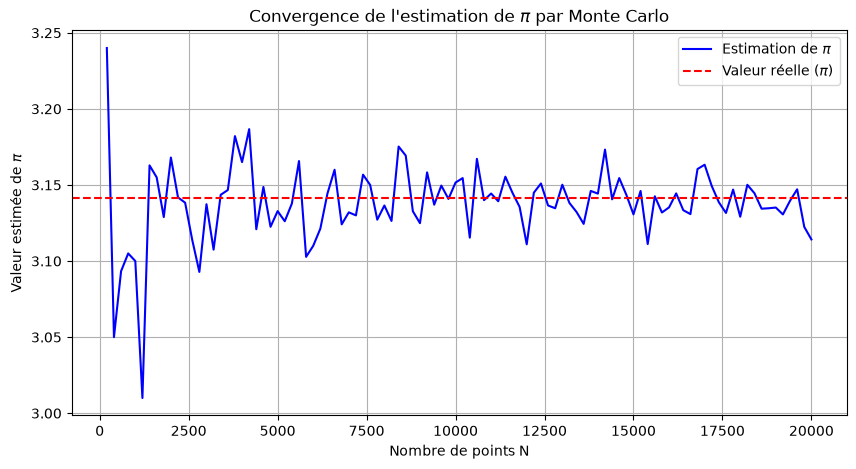

Probabilité de réaction estimée (E >= 65.0) : 0.1595 (soit 15.96%)


In [4]:
# 1. Monte Carlo pi estimation
def estimate_pi(N):
    """Génère N points aléatoires dans un carré de côté 2 [-1, 1] et compte

    combien tombent dans le cercle unité (distance <= 1)
    """
    x = np.random.uniform(-1, 1, N)
    y = np.random.uniform(-1, 1, N)

    # Condition x^2 + y^2 <= 1 pour être dans le cercle unité
    inside_circle = np.sum(x**2 + y**2 <= 1.0)

    # Rapport d'aires : Aire(Cercle) / Aire(Carré) = (pi * 1^2) / (2 * 2) = pi / 4
    pi_estimate = 4 * inside_circle / N
    return pi_estimate


def plot_pi_convergence(max_N=10000, step=100):
    """Affiche la convergence de l'estimation de pi en fonction de N"""
    N_values = list(range(step, max_N + 1, step))
    pi_estimates = [estimate_pi(n) for n in N_values]

    plt.figure(figsize=(10, 5))
    plt.plot(N_values, pi_estimates, label="Estimation de $\pi$", color="b")
    plt.axhline(
        y=np.pi, color="r", linestyle="--", label="Valeur réelle ($\pi$)"
    )
    plt.xlabel("Nombre de points N")
    plt.ylabel("Valeur estimée de $\pi$")
    plt.title("Convergence de l'estimation de $\pi$ par Monte Carlo")
    plt.legend()
    plt.grid(True)
    plt.show()


# 2. Chemistry-inspired Monte Carlo
def simulate_molecular_collisions(
    M, threshold_energy, distribution="normal", mean_energy=50, std_energy=15
):
    """Simule M collisions moléculaires aléatoires et calcule la probabilité de

    réaction[cite: 1].
    """
    # Assignation d'énergies aléatoires à chaque collision[cite: 1]
    if distribution == "normal":
        energies = np.random.normal(mean_energy, std_energy, M)
    elif distribution == "uniform":
        energies = np.random.uniform(0, mean_energy * 2, M)
    else:
        raise ValueError("Distribution inconnue. Utilisez 'normal' ou 'uniform'.")

    # Nombre de collisions dépassant l'énergie du seuil d'activation[cite: 1]
    reactive_collisions = np.sum(energies >= threshold_energy)

    # La fraction représente une estimation de la probabilité de réaction[cite: 1]
    reaction_probability = reactive_collisions / M

    return reaction_probability


# Tests Part C
print("\n--- Part C Tests ---")
pi_approx = estimate_pi(100000)
print(f"Estimation de pi avec N=100 000 : {pi_approx}")

# Affichage du graphique de convergence de Pi
plot_pi_convergence(max_N=20000, step=200)

# Simulation de collisions moléculaires (M=100 000, Seuil d'activation = 65)
M_collisions = 100000
E_threshold = 65.0
p_react = simulate_molecular_collisions(
    M_collisions, threshold_energy=E_threshold, distribution="normal"
)
print(
    f"Probabilité de réaction estimée (E >= {E_threshold}) : {p_react:.4f} (soit {p_react*100:.2f}%)"
)